<a href="https://colab.research.google.com/github/priyanshi-nigam123/Brain-Tumor-Detection/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize


In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40
LEARNING_RATE = 0.0001

train_dir = '/content/drive/MyDrive/dataset for BT ml/Training'
test_dir = '/content/drive/MyDrive/dataset for BT ml/Testing'

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Image Size: {IMAGE_SIZE}×{IMAGE_SIZE} (improved from 128×128)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print("Model: EfficientNetB0 (improved from VGG16)")
print("=" * 60)

CONFIGURATION
Image Size: 224×224 (improved from 128×128)
Batch Size: 32
Epochs: 40
Learning Rate: 0.0001
Model: EfficientNetB0 (improved from VGG16)


In [ ]:
!cp -r "/content/drive/MyDrive/dataset for BT ml" /content/dataset_local

In [ ]:
train_dir = '/content/dataset_local/Training'
test_dir = '/content/dataset_local/Testing'

In [ ]:
train_augmentation = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)
test_augmentation = ImageDataGenerator()

print("\n" + "=" * 60)
print("DATA AUGMENTATION APPLIED")
print("=" * 60)
print("Rotation (±25°)")
print("Width/Height Shift (±20%)")
print("Horizontal & Vertical Flip")
print("Zoom Range (±20%)")
print("Shear Range (±20%)")
print("Brightness Range (80-120%)")
print("=" * 60)

train_generator = train_augmentation.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_augmentation.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_augmentation.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\nClass names: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")


DATA AUGMENTATION APPLIED
Rotation (±25°)
Width/Height Shift (±20%)
Horizontal & Vertical Flip
Zoom Range (±20%)
Shear Range (±20%)
Brightness Range (80-120%)
Found 4593 images belonging to 4 classes.
Found 1148 images belonging to 4 classes.
Found 1324 images belonging to 4 classes.

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Training samples: 4593
Validation samples: 1148
Test samples: 1324


In [ ]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("\n" + "=" * 60)
print("CLASS WEIGHTS (For Imbalanced Data)")
print("=" * 60)
for i, weight in class_weight_dict.items():
    print(f"{class_names[i]}: {weight:.3f}")
print("=" * 60)


CLASS WEIGHTS (For Imbalanced Data)
glioma: 1.086
meningioma: 1.067
notumor: 0.891
pituitary: 0.980


In [ ]:
print("\nBuilding EfficientNetB0 model...")

# Load pre-trained EfficientNetB0
base_model = EfficientNetB0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze most layers, unfreeze last layers for fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Unfreeze last 30 layers for fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for layer in base_model.layers if layer.trainable)}")

# Build complete model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),

    # Dense layers with BatchNormalization & Dropout
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])
# Compile model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Print model summary
print("\n" + "=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()
print("=" * 60)



Building EfficientNetB0 model...
Total layers: 238
Trainable layers: 23

MODEL ARCHITECTURE


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,873,767 (18.59 MB)

 Trainable params: 2,305,764 (8.80 MB)

 Non-trainable params: 2,568,003 (9.80 MB)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Save best model
model_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_brain_tumor_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [ ]:
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,   # Handle class imbalance
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")


TRAINING MODEL
Epoch 1/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - loss: 1.5520 - sparse_categorical_accuracy: 0.4301
Epoch 1: val_loss improved from 1.27865 to 0.86325, saving model to /content/drive/MyDrive/best_brain_tumor_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 165s 933ms/step - loss: 1.2230 - sparse_categorical_accuracy: 0.5535 - val_loss: 0.8633 - val_sparse_categorical_accuracy: 0.6568 - learning_rate: 1.0000e-04
Epoch 2/40
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - loss: 0.8192 - sparse_categorical_accuracy: 0.6943
Epoch 2: val_loss improved from 0.86325 to 0.73961, saving model to /content/drive/MyDrive/best_brain_tumor_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_brain_tumor_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 107s 744ms/step - loss: 0.7560 - sparse_categorical_accuracy: 0.7207 - val_loss: 0.7396 - val_sparse_categorical_accuracy: 0.7247 - learning

In [ ]:
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_generator.reset()
test_predictions = model.predict(test_generator, steps=int(np.ceil(test_generator.samples / BATCH_SIZE)))

test_predictions = test_predictions[:test_generator.samples]
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_labels_encoded = test_generator.classes

accuracy = accuracy_score(test_labels_encoded, test_predictions_classes)
f1_weighted = f1_score(test_labels_encoded, test_predictions_classes, average='weighted')
f1_macro = f1_score(test_labels_encoded, test_predictions_classes, average='macro')

print(f"\nAccuracy: {accuracy:.4f} (Goal: >95%)")
print(f"F1-Score (weighted): {f1_weighted:.4f}")
print(f"F1-Score (macro): {f1_macro:.4f}")

# Classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    test_labels_encoded,
    test_predictions_classes,
    target_names=class_names,
    digits=4
))



MODEL EVALUATION
42/42 ━━━━━━━━━━━━━━━━━━━━ 370s 9s/step

Accuracy: 0.9313 (Goal: >95%)
F1-Score (weighted): 0.9302
F1-Score (macro): 0.9263

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.8742    0.9500    0.9105       300
  meningioma     0.9387    0.8007    0.8642       306
     notumor     0.9800    0.9704    0.9752       405
   pituitary     0.9226    0.9904    0.9553       313

    accuracy                         0.9313      1324
   macro avg     0.9289    0.9279    0.9263      1324
weighted avg     0.9329    0.9313    0.9302      1324



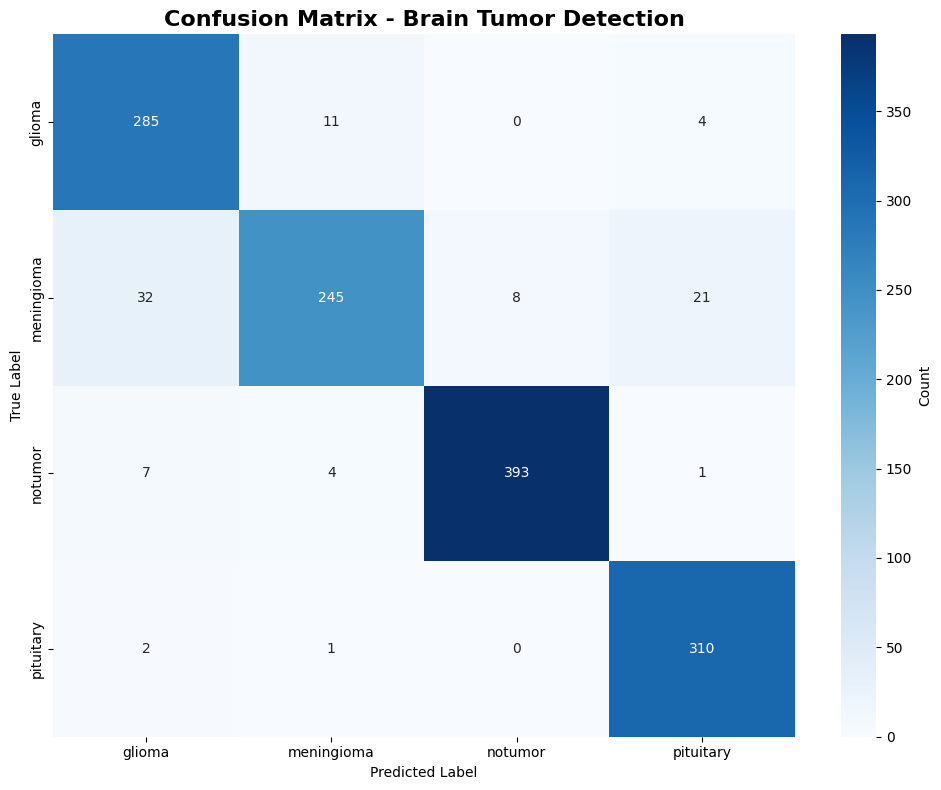

In [ ]:
cm = confusion_matrix(test_labels_encoded, test_predictions_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Brain Tumor Detection', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

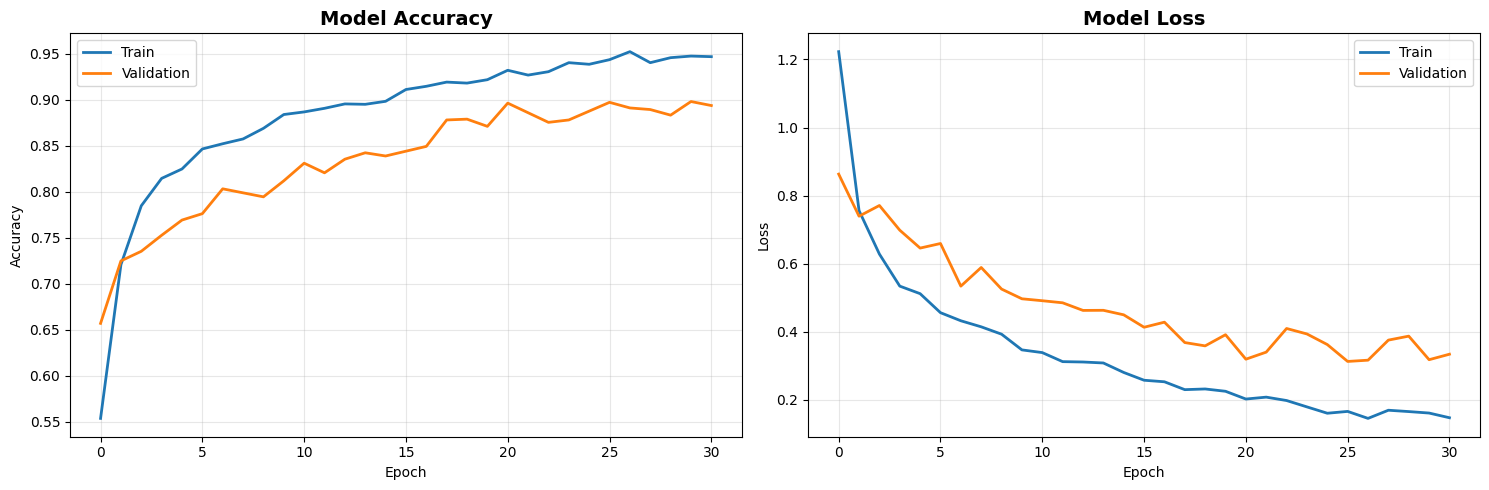

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['sparse_categorical_accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_sparse_categorical_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

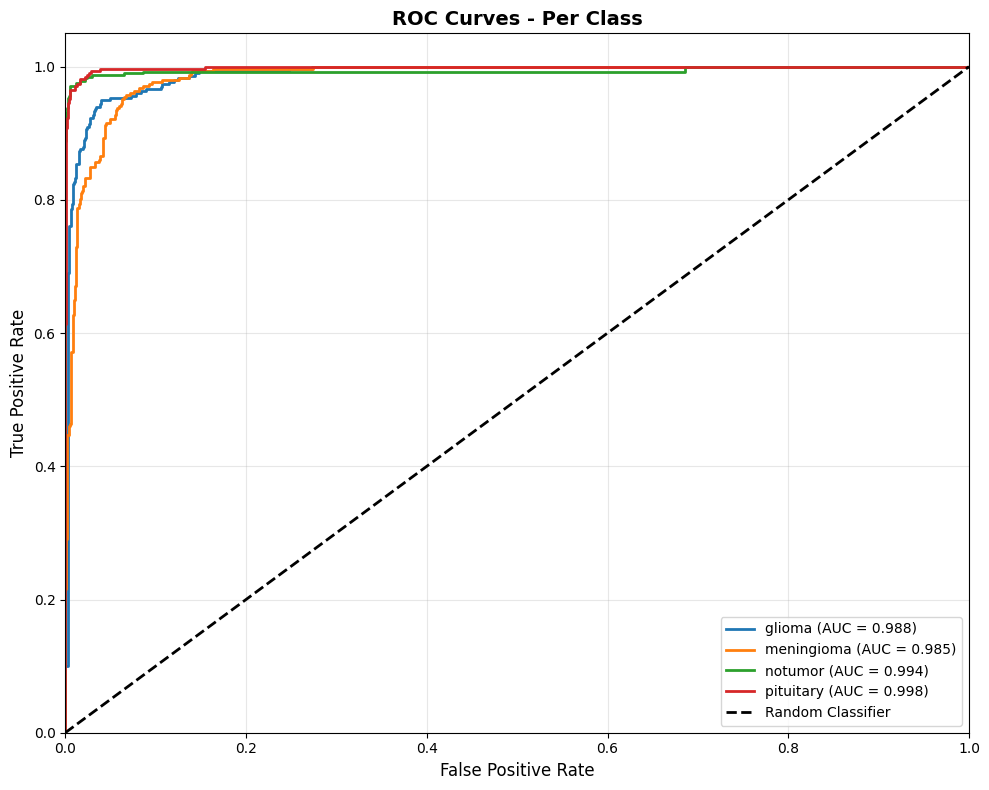

In [ ]:
test_labels_bin = label_binarize(test_labels_encoded, classes=range(num_classes))

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Per Class', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

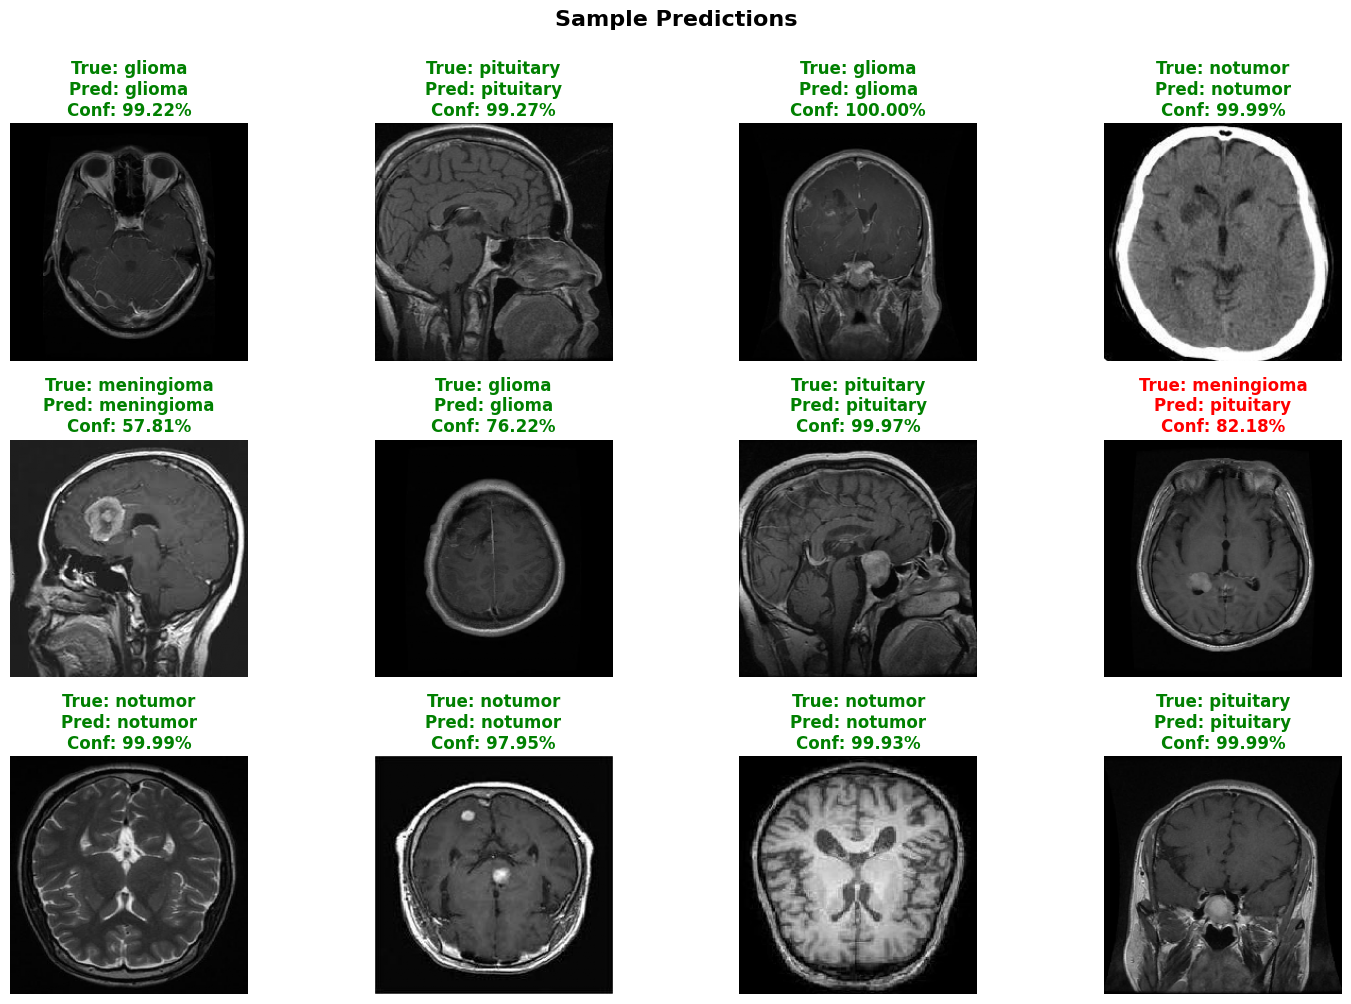

In [ ]:
test_filepaths = [os.path.join(test_dir, fname) for fname in test_generator.filenames]

plt.figure(figsize=(15, 10))

random_indices = np.random.choice(len(test_filepaths), 12, replace=False)

for idx, i in enumerate(random_indices):
    ax = plt.subplot(3, 4, idx + 1)
    img = load_img(test_filepaths[i], target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img) / 255.0

    pred_class_idx = test_predictions_classes[i]
    true_class_idx = test_labels_encoded[i]
    confidence = np.max(test_predictions[i])

    # Check if correct
    is_correct = pred_class_idx == true_class_idx
    color = 'green' if is_correct else 'red'

    ax.imshow(img_array)
    ax.set_title(
        f'True: {class_names[true_class_idx]}\n'
        f'Pred: {class_names[pred_class_idx]}\n'
        f'Conf: {confidence:.2%}',
        color=color,
        fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Sample Predictions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
print("\nSaving model...")
model.save('/content/drive/MyDrive/brain_tumor_efficientnet_model.keras')
print("✓ Model saved: brain_tumor_efficientnet_model.keras")


Saving model...
✓ Model saved: brain_tumor_efficientnet_model.keras


In [ ]:
print("\n" + "=" * 60)
print("IMPROVEMENTS SUMMARY")
print("=" * 60)
print(f"VGG16 (82%) → EfficientNetB0 ({accuracy:.1%})")
print(f"Image Size: 128×128 → {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"Epochs: 10 → {EPOCHS}")
print(f"Added BatchNormalization layers")
print(f"Advanced data augmentation")
print(f"Class weights for imbalance")
print(f"Learning rate scheduling")
print(f"Early stopping & model checkpointing")
print(f"Memory-efficient batch loading (flow_from_directory)")
print(f"Better metrics: F1-score, AUC-ROC, per-class analysis")
print("=" * 60)

print("\n TRAINING COMPLETE! Model deployed and saved.")


IMPROVEMENTS SUMMARY
VGG16 (82%) → EfficientNetB0 (93.1%)
Image Size: 128×128 → 224×224
Epochs: 10 → 40
Added BatchNormalization layers
Advanced data augmentation
Class weights for imbalance
Learning rate scheduling
Early stopping & model checkpointing
Memory-efficient batch loading (flow_from_directory)
Better metrics: F1-score, AUC-ROC, per-class analysis

 TRAINING COMPLETE! Model deployed and saved.
